# Historical Pool Data — FinTech 590
Fetches daily historical TVL, APY, and impermanent loss for each pool in `data/top_pools.parquet`.

**Run `defi_pipeline.ipynb` first** to generate the pool list.

Data source: [DeFiLlama Chart API](https://yields.llama.fi/docs) — free, no API key required.  
Coverage: daily data from **March 2022 → present** (~1,400+ data points per pool).

## 0. Imports

In [1]:
import time, pathlib
import requests
import pandas as pd
from dotenv import load_dotenv

POOLS_PARQUET   = pathlib.Path("data/top_pools.parquet")
HISTORY_PARQUET = pathlib.Path("data/pool_history.parquet")
CHART_URL       = "https://yields.llama.fi/chart/"
DELAY           = 1.5    # seconds between requests
RETRY_WAIT      = 60     # seconds to wait after a 403/429 before retrying
MAX_RETRIES     = 2

print("Ready.")

Ready.


## 1. Load Pool List

In [2]:
pools = pd.read_parquet(POOLS_PARQUET)
print(f"Loaded {len(pools)} pools from {POOLS_PARQUET}")
pools[["chain", "address", "token0", "token1", "fee_tier", "llama_id"]]

Loaded 47 pools from data\top_pools.parquet


,chain,address,token0,token1,fee_tier,llama_id
0,Ethereum,0x88e6A0c2dDD26FEEb64F039a2c41296FcB3f5640,USDC,WETH,500,665dc8bc-c79d-4800-97f7-304bf368e547
1,Ethereum,0x4e68Ccd3E89f51C3074ca5072bbAC773960dFa36,WETH,USDT,3000,fc9f488e-8183-416f-a61e-4e5c571d4395
2,Ethereum,0x4585FE77225b41b697C938B018E2Ac67Ac5a20c0,WBTC,WETH,500,d59a5728-d391-4989-86f6-a94e11e0eb3b
3,Ethereum,0xCBCdF9626bC03E24f779434178A73a0B4bad62eD,WBTC,WETH,3000,c5599b3a-ea73-4017-a867-72eb971301d1
4,Ethereum,0xe8f7c89C5eFa061e340f2d2F206EC78FD8f7e124,WBTC,CBBTC,100,c0bbcf6c-9454-4773-a19f-c6486484c287
5,Ethereum,0xC5c134A1f112efA96003f8559Dba6fAC0BA77692,WHITE,WETH,100,9be33e76-5f9c-435f-a008-e33965f602d8
6,Ethereum,0x99ac8cA7087fA4A2A1FB6357269965A2014ABc35,WBTC,USDC,3000,bbecbf69-a4f7-43e3-8b72-de180d106e2c
7,Ethereum,0x3416cF6C708Da44DB2624D63ea0AAef7113527C6,USDC,USDT,100,e737d721-f45c-40f0-9793-9f56261862b9
8,Ethereum,0x9Db9e0e53058C89e5B94e29621a205198648425B,WBTC,USDT,3000,2608e751-41d4-47db-9b9c-4bf3a757fc1b
9,Ethereum,0xbAFeAd7c60Ea473758ED6c6021505E8BBd7e8E5d,AUSD,USDC,100,458a64c5-2f64-4ca6-8be7-41b8aef029eb


## 2. Fetch Historical Data

For each pool, calls `yields.llama.fi/chart/{llama_id}` which returns daily snapshots with:

| Field | Description |
|-------|-------------|
| `tvl_usd` | Total value locked (USD) |
| `apy` | Total APY (fees + rewards) |
| `apy_base` | APY from trading fees only |
| `apy_base_7d` | 7-day rolling average base APY |
| `il_7d` | 7-day impermanent loss (%) |

In [3]:
all_records = []

for _, pool in pools.iterrows():
    label = f"[{pool['chain']}] {pool['token0']}/{pool['token1']} {pool['fee_tier']/1e4:.2f}%"
    print(f"  Fetching {label} ...", end="", flush=True)

    data = []
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            r = requests.get(CHART_URL + pool["llama_id"], timeout=30)
            if r.status_code in (403, 429):
                if attempt < MAX_RETRIES:
                    print(f"  rate-limited, waiting {RETRY_WAIT}s ...", end="", flush=True)
                    time.sleep(RETRY_WAIT)
                    continue
                else:
                    print(f"  ERROR: {r.status_code} after {MAX_RETRIES} attempts")
                    break
            r.raise_for_status()
            data = r.json().get("data", [])
            break
        except requests.RequestException as e:
            print(f"  ERROR: {e}")
            break

    for point in data:
        all_records.append({
            "address":     pool["address"],
            "chain":       pool["chain"],
            "token0":      pool["token0"],
            "token1":      pool["token1"],
            "fee_tier":    pool["fee_tier"],
            "date":        point["timestamp"][:10],
            "tvl_usd":     point.get("tvlUsd"),
            "apy":         point.get("apy"),
            "apy_base":    point.get("apyBase"),
            "apy_base_7d": point.get("apyBase7d"),
            "il_7d":       point.get("il7d"),
        })

    if data:
        print(f"  {len(data)} days")

    time.sleep(DELAY)

print(f"\nTotal records collected: {len(all_records):,}")

  Fetching [Ethereum] USDC/WETH 0.05% ...  1433 days
  Fetching [Ethereum] WETH/USDT 0.30% ...  1453 days
  Fetching [Ethereum] WBTC/WETH 0.05% ...  1453 days
  Fetching [Ethereum] WBTC/WETH 0.30% ...  1453 days
  Fetching [Ethereum] WBTC/CBBTC 0.01% ...  528 days
  Fetching [Ethereum] WHITE/WETH 0.01% ...  826 days
  Fetching [Ethereum] WBTC/USDC 0.30% ...  1433 days
  Fetching [Ethereum] USDC/USDT 0.01% ...  1433 days
  Fetching [Ethereum] WBTC/USDT 0.30% ...  1453 days
  Fetching [Ethereum] AUSD/USDC 0.01% ...  105 days
  Fetching [Ethereum] USDC/WETH 0.30% ...  1433 days
  Fetching [Ethereum] LINK/WETH 0.30% ...  1453 days
  Fetching [Ethereum] USDM/USDT 0.05% ...  864 days
  Fetching [Ethereum] WM/USDC 0.01% ...  539 days
  Fetching [Ethereum] WBTC/USDT 0.05% ...  714 days
  Fetching [Ethereum] UNI/WETH 0.30% ...  1453 days
  Fetching [Ethereum] TBTC/WBTC 0.01% ...  595 days
  Fetching [Ethereum] WETH/WEETH 0.05% ...  779 days
  Fetching [Ethereum] USDT/USDF 0.01% ...  381 days
  

## 3. Save to Parquet

In [4]:
df = pd.DataFrame(all_records)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["chain", "address", "date"]).reset_index(drop=True)

df.to_parquet(HISTORY_PARQUET, index=False, engine="pyarrow")

print(f"Saved {len(df):,} rows to {HISTORY_PARQUET}")
print(f"Date range : {df['date'].min().date()}  →  {df['date'].max().date()}")
print(f"Pools      : {df['address'].nunique()} addresses across {df['chain'].nunique()} chains")
print()
df.head(10)

Saved 36,994 rows to data\pool_history.parquet
Date range : 2022-03-27  →  2026-03-26
Pools      : 47 addresses across 4 chains



,address,chain,token0,token1,fee_tier,date,tvl_usd,apy,apy_base,apy_base_7d,il_7d
0,0x0E4831319A50228B9e450861297aB92dee15B44F,Arbitrum,WBTC,USDC,500,2023-07-01,5417,0.0,0.0,NaN,-0.00219
1,0x0E4831319A50228B9e450861297aB92dee15B44F,Arbitrum,WBTC,USDC,500,2023-07-02,1371,0.0,0.0,NaN,-0.00380
2,0x0E4831319A50228B9e450861297aB92dee15B44F,Arbitrum,WBTC,USDC,500,2023-07-03,1375,0.0,0.0,NaN,-0.08092
3,0x0E4831319A50228B9e450861297aB92dee15B44F,Arbitrum,WBTC,USDC,500,2023-07-04,1163,0.0,0.0,NaN,-0.00390
4,0x0E4831319A50228B9e450861297aB92dee15B44F,Arbitrum,WBTC,USDC,500,2023-07-05,1159,0.0,0.0,NaN,-0.01687
5,0x0E4831319A50228B9e450861297aB92dee15B44F,Arbitrum,WBTC,USDC,500,2023-07-06,32188,0.0,0.0,NaN,-0.00634
6,0x0E4831319A50228B9e450861297aB92dee15B44F,Arbitrum,WBTC,USDC,500,2023-07-07,32205,0.0,0.0,0.0,-0.00134
7,0x0E4831319A50228B9e450861297aB92dee15B44F,Arbitrum,WBTC,USDC,500,2023-07-08,45717,0.0,0.0,0.0,-0.01350
8,0x0E4831319A50228B9e450861297aB92dee15B44F,Arbitrum,WBTC,USDC,500,2023-07-09,53033,0.0,0.0,0.0,-0.02561
9,0x0E4831319A50228B9e450861297aB92dee15B44F,Arbitrum,WBTC,USDC,500,2023-07-10,52313,0.0,0.0,0.0,-0.06613


## 4. Quick Sanity Checks

In [5]:
# Records per pool
print("Days of history per pool:")
summary = (
    df.groupby(["chain", "token0", "token1", "fee_tier"])
    .agg(days=("date", "count"), earliest=("date", "min"), latest=("date", "max"))
    .reset_index()
)
summary["fee_pct"] = summary["fee_tier"] / 1e4
summary.drop(columns="fee_tier", inplace=True)
print(summary.to_string(index=False))

Days of history per pool:
   chain   token0   token1  days   earliest     latest  fee_pct
Arbitrum     CAPX     USDC   141 2025-11-06 2026-03-26     0.01
Arbitrum    HEGIC     WETH   797 2023-12-02 2026-03-26     0.05
Arbitrum      LON     USDC   440 2025-01-11 2026-03-26     0.30
Arbitrum     RAIN     WETH   158 2025-10-20 2026-03-26     0.01
Arbitrum     USDC   THBILL   232 2025-08-07 2026-03-26     0.01
Arbitrum     USDC     USDT   959 2023-06-11 2026-03-26     0.01
Arbitrum     WBTC      ARB   992 2023-04-03 2026-03-26     0.30
Arbitrum     WBTC    CBBTC   485 2024-11-22 2026-03-26     0.01
Arbitrum     WBTC     USDC   939 2023-07-01 2026-03-26     0.05
Arbitrum     WBTC     WETH  1397 2022-03-27 2026-03-26     0.05
Arbitrum     WETH      GMX  1397 2022-03-27 2026-03-26     1.00
    Base     BALD     WETH   819 2023-08-08 2026-03-26     1.00
    Base DEFI.SSI     USDC   409 2024-12-25 2026-03-26     0.30
    Base      MPP     USDC    23 2026-02-27 2026-03-26     0.30
    Base     U

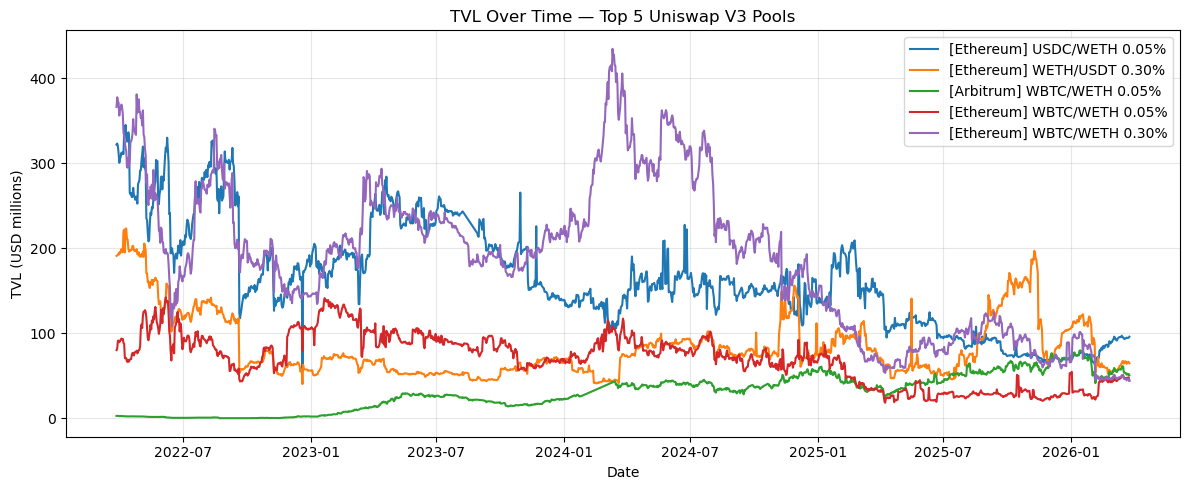

Chart saved to data/tvl_history.png


In [6]:
# TVL over time for top 5 pools by current TVL
import matplotlib.pyplot as plt

top5 = pools.nlargest(5, "tvl_usd")[["address", "chain"]].values.tolist()
fig, ax = plt.subplots(figsize=(12, 5))

for addr, chain in top5:
    subset = df[(df["address"] == addr) & (df["chain"] == chain)]
    row    = pools[(pools["address"] == addr) & (pools["chain"] == chain)].iloc[0]
    label  = f"[{row['chain']}] {row['token0']}/{row['token1']} {row['fee_tier']/1e4:.2f}%"
    ax.plot(subset["date"], subset["tvl_usd"] / 1e6, label=label)

ax.set_title("TVL Over Time — Top 5 Uniswap V3 Pools")
ax.set_ylabel("TVL (USD millions)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("data/tvl_history.png", dpi=150)
plt.show()
print("Chart saved to data/tvl_history.png")

## 5. Dune Analytics Backfill (May 2021 → March 2022)

DeFiLlama's yields API only goes back to **March 2022**.  
This section queries Dune Analytics (on-chain Uniswap V3 events) to fill the
**~10-month gap** for the Ethereum pools that existed at the V3 launch.

| Source | Coverage |
|--------|----------|
| DeFiLlama | 2022-03-27 → present |
| **Dune backfill** | **2021-05-01 → 2022-03-26** |

**Data computed:**
- `tvl_usd` — cumulative Mint − Burn token balances × daily USD prices (`prices.usd`)
- `volume_usd` — swap volume in USD (`dex.trades`)
- `apy_base` — estimated as `(volume_usd × fee_rate / tvl_usd) × 365 × 100`
- `apy`, `apy_base_7d`, `il_7d` — left as NaN (require more complex on-chain computation)

In [ ]:
## 5-A  Configuration & Dune API helpers
import os, time
import requests

from dotenv import load_dotenv
load_dotenv()
DUNE_API_KEY = os.environ.get("DUNE_API_KEY", "")
DUNE_BASE    = "https://api.dune.com/api/v1"
DUNE_HEADERS = {"X-Dune-API-Key": DUNE_API_KEY, "Content-Type": "application/json"}

GAP_START = "2021-05-01"
GAP_END   = "2022-03-26"   # inclusive; DeFiLlama starts 2022-03-27

# Eligible pools: Ethereum-only, earliest DeFiLlama record ≤ 2022-03-28
earliest_by_pool = df[df["chain"] == "Ethereum"].groupby("address")["date"].min()
eligible_addrs   = earliest_by_pool[earliest_by_pool <= "2022-03-28"].index.tolist()
ELIGIBLE = pools[
    pools["address"].isin(eligible_addrs) & (pools["chain"] == "Ethereum")
].copy()
print(f"Eligible pools for backfill: {len(ELIGIBLE)}")
print(ELIGIBLE[["token0", "token1", "fee_tier", "address"]].to_string(index=False))


# ── Dune helpers ──────────────────────────────────────────────────────────────
def dune_execute_sql(sql: str, performance: str = "medium") -> str:
    """Submit raw SQL to Dune Execute-SQL endpoint; returns execution_id."""
    r = requests.post(
        f"{DUNE_BASE}/sql/execute",          # v1 raw-SQL endpoint
        headers=DUNE_HEADERS,
        json={"sql": sql, "performance": performance},
        timeout=30,
    )
    if not r.ok:
        raise RuntimeError(f"Dune submit failed {r.status_code}: {r.text}")
    return r.json()["execution_id"]


def dune_poll(execution_id: str, poll_sec: int = 10, max_wait: int = 720) -> list:
    """Poll until execution completes; return result rows (auto-paginated)."""
    deadline = time.time() + max_wait
    while time.time() < deadline:
        r = requests.get(
            f"{DUNE_BASE}/execution/{execution_id}/status",
            headers=DUNE_HEADERS, timeout=30,
        )
        r.raise_for_status()
        state = r.json().get("state", "")
        print(f"  [{execution_id[:12]}…] {state}          ", end="\r", flush=True)
        if state == "QUERY_STATE_COMPLETED":
            break
        if state in ("QUERY_STATE_FAILED", "QUERY_STATE_CANCELLED"):
            raise RuntimeError(f"Dune execution {execution_id} ended: {state}")
        time.sleep(poll_sec)
    else:
        raise TimeoutError(f"Execution {execution_id} timed out after {max_wait}s")
    print()

    rows, offset = [], 0
    while True:
        r = requests.get(
            f"{DUNE_BASE}/execution/{execution_id}/results",
            headers=DUNE_HEADERS,
            params={"limit": 1000, "offset": offset},
            timeout=30,
        )
        r.raise_for_status()
        batch = r.json().get("result", {}).get("rows", [])
        rows.extend(batch)
        if len(batch) < 1000:
            break
        offset += 1000
    return rows

print("Helpers ready.")


In [ ]:
## 5-B  Build SQL queries

# Each eligible pool's two underlying token addresses + decimals.
# token0/token1 order must match Uniswap V3 pool storage (sorted by address).
POOL_META = {
    # pool_address_lower : (token0_addr, token1_addr, decimals0, decimals1)
    "0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640": ("0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48", "0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2", 6,  18),  # USDC/WETH 0.05%
    "0x4e68ccd3e89f51c3074ca5072bbac773960dfa36": ("0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2", "0xdac17f958d2ee523a2206206994597c13d831ec7", 18, 6),   # WETH/USDT 0.30%
    "0x4585fe77225b41b697c938b018e2ac67ac5a20c0": ("0x2260fac5e5542a773aa44fbcfedf7c193bc2c599", "0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2", 8,  18),  # WBTC/WETH 0.05%
    "0xcbcdf9626bc03e24f779434178a73a0b4bad62ed": ("0x2260fac5e5542a773aa44fbcfedf7c193bc2c599", "0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2", 8,  18),  # WBTC/WETH 0.30%
    "0x9db9e0e53058c89e5b94e29621a205198648425b": ("0x2260fac5e5542a773aa44fbcfedf7c193bc2c599", "0xdac17f958d2ee523a2206206994597c13d831ec7", 8,  6),   # WBTC/USDT 0.30%
    "0x8ad599c3a0ff1de082011efddc58f1908eb6e6d8": ("0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48", "0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2", 6,  18),  # USDC/WETH 0.30%
    "0x99ac8ca7087fa4a2a1fb6357269965a2014abc35": ("0x2260fac5e5542a773aa44fbcfedf7c193bc2c599", "0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48", 8,  6),   # WBTC/USDC 0.30%
    "0x3416cf6c708da44db2624d63ea0aaef7113527c6": ("0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48", "0xdac17f958d2ee523a2206206994597c13d831ec7", 6,  6),   # USDC/USDT 0.01%
    "0xa6cc3c2531fdaa6ae1a3ca84c2855806728693e8": ("0x514910771af9ca656af840dff83e8264ecf986ca", "0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2", 18, 18),  # LINK/WETH 0.30%
    "0x1d42064fc4beb5f8aaf85f4617ae8b3b5b8bd801": ("0x1f9840a85d5af5bf1d1762f925bdaddc4201f984", "0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2", 18, 18),  # UNI/WETH  0.30%
}

STABLECOINS = {
    "0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48",  # USDC
    "0xdac17f958d2ee523a2206206994597c13d831ec7",  # USDT
}
PRICE_TOKENS = sorted({
    tok
    for tok0, tok1, _, _ in POOL_META.values()
    for tok in (tok0, tok1)
    if tok not in STABLECOINS
})

# DuneSQL addresses are varbinary — use from_hex() (strips 0x, returns varbinary)
pool_hex_in  = ", ".join(f"from_hex(\'{p[2:]}\')" for p in POOL_META)
price_hex_in = ", ".join(f"from_hex(\'{t[2:]}\')" for t in PRICE_TOKENS)
pool_vals    = ",\n        ".join(
    f"(from_hex(\'{pool[2:]}\'), from_hex(\'{tok0[2:]}\'), from_hex(\'{tok1[2:]}\'), {dec0}, {dec1})"
    for pool, (tok0, tok1, dec0, dec1) in POOL_META.items()
)

# Uniswap V3 event topic0 selectors
MINT_SELECTOR = "0x7a53080ba414158be7ec69b987b5fb7d07dee101fe85488f0853ae16239d0bde"
BURN_SELECTOR = "0x0c396cd989a39f4459b5fa1aed6a9a8dcdbc45908acfd67e028cd568da98982c"

# ── Query 1: Daily swap volume ─────────────────────────────────────────────────
# project_contract_address is varbinary in dex.trades — compare with from_hex()
SQL_VOLUME = f"""
SELECT
    '0x' || lower(to_hex(project_contract_address)) AS pool_address,
    CAST(DATE_TRUNC('day', block_time) AS DATE)       AS date,
    SUM(amount_usd)                                     AS volume_usd
FROM dex.trades
WHERE blockchain = 'ethereum'
  AND project    = 'uniswap'
  AND version    = '3'
  AND block_time >= TIMESTAMP '{GAP_START} 00:00:00'
  AND block_time <= TIMESTAMP '{GAP_END} 23:59:59'
  AND project_contract_address IN ({pool_hex_in})
GROUP BY 1, 2
ORDER BY 1, 2
"""

# ── Query 2: Daily TVL via ethereum.logs ──────────────────────────────────────
# uniswap_v3_ethereum.Pool_evt_Mint/Burn no longer exist in DuneSQL;
# use ethereum.logs with the known Mint/Burn event selectors instead.
# Mint/Burn data layout: [32B amount][32B amount0][32B amount1]
SQL_TVL = f"""
WITH
pool_info AS (
    SELECT * FROM (VALUES
        {pool_vals}
    ) AS t(pool, tok0, tok1, dec0, dec1)
),
mints AS (
    SELECT
        l.contract_address                                                                   AS pool,
        CAST(DATE_TRUNC('day', l.block_time) AS DATE)                                      AS day,
        SUM(CAST(bytearray_to_uint256(bytearray_substring(l.data, 33, 32)) AS DOUBLE)
            / POW(10.0, CAST(p.dec0 AS DOUBLE)))                                             AS d0,
        SUM(CAST(bytearray_to_uint256(bytearray_substring(l.data, 65, 32)) AS DOUBLE)
            / POW(10.0, CAST(p.dec1 AS DOUBLE)))                                             AS d1
    FROM ethereum.logs l
    JOIN pool_info p ON l.contract_address = p.pool
    WHERE l.topic0     = {MINT_SELECTOR}
      AND l.block_time < TIMESTAMP '2022-03-27 00:00:00'
    GROUP BY 1, 2
),
burns AS (
    SELECT
        l.contract_address                                                                   AS pool,
        CAST(DATE_TRUNC('day', l.block_time) AS DATE)                                      AS day,
        -SUM(CAST(bytearray_to_uint256(bytearray_substring(l.data, 33, 32)) AS DOUBLE)
             / POW(10.0, CAST(p.dec0 AS DOUBLE)))                                            AS d0,
        -SUM(CAST(bytearray_to_uint256(bytearray_substring(l.data, 65, 32)) AS DOUBLE)
             / POW(10.0, CAST(p.dec1 AS DOUBLE)))                                            AS d1
    FROM ethereum.logs l
    JOIN pool_info p ON l.contract_address = p.pool
    WHERE l.topic0     = {BURN_SELECTOR}
      AND l.block_time < TIMESTAMP '2022-03-27 00:00:00'
    GROUP BY 1, 2
),
daily_net AS (
    SELECT pool, day, SUM(d0) AS net0, SUM(d1) AS net1
    FROM (SELECT * FROM mints UNION ALL SELECT * FROM burns)
    GROUP BY 1, 2
),
cumul AS (
    SELECT
        pool, day,
        SUM(net0) OVER (PARTITION BY pool ORDER BY day
                        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS bal0,
        SUM(net1) OVER (PARTITION BY pool ORDER BY day
                        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS bal1
    FROM daily_net
),
gap AS (
    SELECT * FROM cumul
    WHERE day >= DATE '{GAP_START}' AND day <= DATE '{GAP_END}'
),
tok_prices AS (
    SELECT
        '0x' || lower(to_hex(contract_address))            AS tok,
        CAST(DATE_TRUNC('day', minute) AS DATE)             AS day,
        AVG(price)                                            AS price
    FROM prices.usd
    WHERE blockchain       = 'ethereum'
      AND contract_address IN ({price_hex_in})
      AND minute >= TIMESTAMP '{GAP_START} 00:00:00'
      AND minute  < TIMESTAMP '2022-03-27 00:00:00'
    GROUP BY 1, 2
)
SELECT
    '0x' || lower(to_hex(g.pool))  AS pool_address,
    g.day                             AS date,
    GREATEST(0.0,
        g.bal0 * COALESCE(p0.price, 1.0) +
        g.bal1 * COALESCE(p1.price, 1.0)
    )                                 AS tvl_usd
FROM gap g
JOIN pool_info pi ON g.pool = pi.pool
LEFT JOIN tok_prices p0 ON '0x' || lower(to_hex(pi.tok0)) = p0.tok AND g.day = p0.day
LEFT JOIN tok_prices p1 ON '0x' || lower(to_hex(pi.tok1)) = p1.tok AND g.day = p1.day
ORDER BY 1, 2
"""

print(f"SQL_VOLUME  {len(SQL_VOLUME):,} chars")
print(f"SQL_TVL     {len(SQL_TVL):,} chars")


In [ ]:
## 5-C  Execute both Dune queries (runs in parallel — submit first, then poll)

print("Submitting Volume query …")
vol_eid = dune_execute_sql(SQL_VOLUME)
print(f"  execution_id = {vol_eid}")

print("Submitting TVL query …")
tvl_eid = dune_execute_sql(SQL_TVL)
print(f"  execution_id = {tvl_eid}")

# Poll volume (typically faster — dex.trades is pre-indexed)
print("\nWaiting for Volume result …")
vol_rows = dune_poll(vol_eid)
print(f"  Volume rows: {len(vol_rows):,}")

print("Waiting for TVL result …")
tvl_rows = dune_poll(tvl_eid)
print(f"  TVL rows:    {len(tvl_rows):,}")

In [ ]:
## 5-D  Build backfill DataFrame

tvl_df = pd.DataFrame(tvl_rows)
vol_df = pd.DataFrame(vol_rows)

# Normalise addresses to lowercase
tvl_df["pool_address"] = tvl_df["pool_address"].str.lower()
vol_df["pool_address"] = vol_df["pool_address"].str.lower()

tvl_df["date"] = pd.to_datetime(tvl_df["date"])
vol_df["date"] = pd.to_datetime(vol_df["date"])
tvl_df["tvl_usd"] = pd.to_numeric(tvl_df["tvl_usd"], errors="coerce")
vol_df["volume_usd"] = pd.to_numeric(vol_df["volume_usd"], errors="coerce")

# Outer-merge so we keep days that appear in only one source
merged = tvl_df.merge(vol_df, on=["pool_address", "date"], how="outer")

# Attach pool metadata (token0, token1, fee_tier, chain) from the pools table
pool_lookup = (
    pools[pools["chain"] == "Ethereum"][["address", "chain", "token0", "token1", "fee_tier"]]
    .assign(address=lambda x: x["address"].str.lower())
    .rename(columns={"address": "pool_address"})
)
backfill = merged.merge(pool_lookup, on="pool_address", how="left")

# ── Estimate apy_base ─────────────────────────────────────────────────────────
# fee_revenue_per_day ≈ volume_usd × fee_rate  (fee_tier is in ppm: 500 → 0.05%)
# annualised fee APY   = (fee_revenue / tvl_usd) × 365 × 100
fee_tier_map = pools.set_index(pools["address"].str.lower())["fee_tier"].to_dict()
backfill["fee_rate"] = backfill["pool_address"].map(fee_tier_map) / 1e6
backfill["apy_base"] = (
    backfill["volume_usd"] * backfill["fee_rate"] / backfill["tvl_usd"]
) * 365 * 100
backfill.loc[backfill["tvl_usd"].isna() | (backfill["tvl_usd"] <= 0), "apy_base"] = float("nan")
backfill.loc[backfill["volume_usd"].isna(), "apy_base"] = float("nan")

# ── Restore original address casing (checksum) ────────────────────────────────
addr_case_map = {a.lower(): a for a in pools["address"]}
backfill["address"] = backfill["pool_address"].map(addr_case_map)

# ── Select and order columns to match pool_history schema ─────────────────────
backfill = backfill.assign(
    apy        = float("nan"),
    apy_base_7d= float("nan"),
    il_7d      = float("nan"),
)[["address", "chain", "token0", "token1", "fee_tier",
   "date", "tvl_usd", "apy", "apy_base", "apy_base_7d", "il_7d"]]

print(f"Backfill rows : {len(backfill):,}")
print(f"Date range    : {backfill['date'].min().date()} → {backfill['date'].max().date()}")
print(f"Pools covered : {backfill['address'].nunique()}")
backfill.head(10)

In [ ]:
## 5-E  Merge backfill with existing DeFiLlama data and save

combined = (
    pd.concat([df, backfill], ignore_index=True)
    # Dedup key: address + date  (DeFiLlama wins if both sources have the same day)
    .sort_values(["address", "date", "tvl_usd"], na_position="last")
    .drop_duplicates(subset=["address", "date"], keep="first")
    .sort_values(["chain", "address", "date"])
    .reset_index(drop=True)
)

combined.to_parquet(HISTORY_PARQUET, index=False, engine="pyarrow")

print(f"Saved {len(combined):,} rows → {HISTORY_PARQUET}")
print(f"Date range : {combined['date'].min().date()}  →  {combined['date'].max().date()}")
print(f"Pools      : {combined['address'].nunique()} addresses across {combined['chain'].nunique()} chains")
print(f"New rows added from Dune: {len(combined) - len(df):,}")

In [ ]:
## 5-F  Validate backfill

print("── Coverage after backfill (Ethereum pools only) ────────────────────────")
eth_check = (
    combined[combined["chain"] == "Ethereum"]
    .groupby(["token0", "token1", "fee_tier"])
    .agg(
        days    =("date", "count"),
        earliest=("date", "min"),
        latest  =("date", "max"),
    )
    .reset_index()
)
eth_check["fee_pct"] = eth_check["fee_tier"] / 1e4
print(eth_check.drop(columns="fee_tier").to_string(index=False))

min_date = combined["date"].min()
print(f"\nSELECT MIN(date) FROM pool_history  →  {min_date.date()}")
assert min_date <= pd.Timestamp("2021-05-31"), \
    f"Backfill did not reach May 2021! Earliest date = {min_date.date()}"
print("Assertion passed: data reaches May 2021.")

print("\n── Sample of earliest backfilled rows ──────────────────────────────────")
print(
    combined[combined["date"] < "2021-06-01"]
    [["chain", "token0", "token1", "fee_tier", "date", "tvl_usd", "apy_base"]]
    .head(15)
    .to_string(index=False)
)